# Домашняя работа: WSD и кластеризация значений слов




In [2]:
# Устанавливаем только то, чего может не быть в чистом Colab.
!pip -q install sentence-transformers gensim

import os
import re
import time
import json
import math
import random
import zipfile
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path('/content') if Path('/content').exists() else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)


def ensure_uploaded(filename: str) -> Path:
    """Находит файл в /content; если его нет в Colab, предлагает загрузить."""
    candidates = list(ROOT.glob(filename)) + list(ROOT.rglob(filename))
    if candidates:
        return candidates[0]

    try:
        from google.colab import files
        print(f'Файл {filename} не найден. Загрузите его в появившемся окне.')
        uploaded = files.upload()
        if filename not in uploaded:
            # Разрешаем Colab переименовать файл, но пытаемся найти zip с тем же началом имени.
            candidates = list(ROOT.glob(filename)) + list(ROOT.glob(filename.replace('.zip', '') + '*.zip'))
            if not candidates:
                raise FileNotFoundError(f'Не найден {filename}')
            return candidates[0]
        return ROOT / filename
    except ImportError:
        raise FileNotFoundError(f'Положите {filename} рядом с тетрадкой.')


def extract_member(zip_path: Path, wanted_name: str, out_dir: Path = DATA_DIR) -> Path:
    """Извлекает конкретный файл из zip, игнорируя __MACOSX."""
    out_path = out_dir / wanted_name
    if out_path.exists():
        return out_path
    with zipfile.ZipFile(zip_path) as zf:
        names = [n for n in zf.namelist() if not n.startswith('__MACOSX/')]
        match = next((n for n in names if Path(n).name == wanted_name), None)
        if match is None:
            raise FileNotFoundError(f'{wanted_name} не найден внутри {zip_path.name}: {names[:10]}')
        with zf.open(match) as src, open(out_path, 'wb') as dst:
            dst.write(src.read())
    return out_path

WSD_ZIP = ensure_uploaded('corpus_wsd_50k.txt.zip')
LENTA_ZIP = ensure_uploaded('lenta.txt.zip')

WSD_PATH = extract_member(WSD_ZIP, 'corpus_wsd_50k.txt')
LENTA_PATH = extract_member(LENTA_ZIP, 'lenta.txt')

print('WSD:', WSD_PATH)
print('Lenta:', LENTA_PATH)


WSD: /content/data/corpus_wsd_50k.txt
Lenta: /content/data/lenta.txt


# Задание 1 — алгоритм Леска

Нужно сравнить два способа сопоставления контекста и словарного определения:

1. **Jaccard** между множествами нормализованных слов контекста и определения WordNet.
2. **Cosine similarity** между sentence embeddings контекста и определения.

Предсказываем только те размеченные примеры, для которых у леммы в WordNet есть **больше одного синсета**. Gold sense используется только при подсчёте accuracy, а не при построении списка кандидатов.

В качестве контекста берём всё предложение: это даёт больше семантического сигнала, чем очень маленькое окно, и не требует подбирать дополнительный гиперпараметр.


In [3]:
import nltk
from nltk.corpus import wordnet as wn
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('stopwords', quiet=True)

EN_STOP = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
TOKEN_RE_EN = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?")


def parse_wsd_corpus(path: Path) -> pd.DataFrame:
    """Преобразует исходный вертикальный формат в таблицу размеченных target-instances."""
    rows = []
    sentence_id = 0
    sentence_tokens = []
    annotated = []

    def flush():
        nonlocal sentence_id, sentence_tokens, annotated, rows
        if not sentence_tokens:
            return
        sentence_text = ' '.join(sentence_tokens)
        for item in annotated:
            rows.append({
                'sentence_id': sentence_id,
                'sentence': sentence_text,
                **item,
            })
        sentence_id += 1
        sentence_tokens = []
        annotated = []

    with open(path, encoding='utf-8') as f:
        for raw in f:
            line = raw.rstrip('\n')
            if not line.strip():
                flush()
                continue
            parts = line.split('\t')
            if len(parts) < 3:
                continue
            sense_key, lemma, surface = parts[0], parts[1], parts[2]
            sentence_tokens.append(surface)
            if sense_key:
                annotated.append({
                    'sense_key': sense_key,
                    'lemma': lemma,
                    'surface': surface,
                })
    flush()
    return pd.DataFrame(rows)

wsd = parse_wsd_corpus(WSD_PATH)
print('Размеченных target-instances:', len(wsd))
print('Предложений:', wsd.sentence_id.nunique())
display(wsd.head())


Размеченных target-instances: 239913
Предложений: 48770


,sentence_id,sentence,sense_key,lemma,surface
0,0,How long has it been since you reviewed the ob...,long%3:00:02::,long,long
1,0,How long has it been since you reviewed the ob...,be%2:42:03::,be,been
2,0,How long has it been since you reviewed the ob...,review%2:31:00::,review,reviewed
3,0,How long has it been since you reviewed the ob...,objective%1:09:00::,objective,objectives
4,0,How long has it been since you reviewed the ob...,benefit%1:21:00::,benefit,benefit


In [4]:
# Строим candidate synsets ТОЛЬКО по лемме. Gold key здесь не используется.

def candidates_for(lemma: str):
    return wn.synsets(lemma.replace(' ', '_'))

candidate_cache = {lemma: candidates_for(lemma) for lemma in wsd['lemma'].unique()}
wsd['n_candidates'] = wsd['lemma'].map(lambda x: len(candidate_cache[x]))

# Оставляем только действительно многозначные слова.
wsd_amb = wsd[wsd['n_candidates'] > 1].copy().reset_index(drop=True)

# Gold synset нужен только для оценки.
def gold_synset_name(key: str):
    try:
        return wn.lemma_from_key(key).synset().name()
    except Exception:
        return None

wsd_amb['gold_synset'] = wsd_amb['sense_key'].map(gold_synset_name)
wsd_amb = wsd_amb.dropna(subset=['gold_synset']).reset_index(drop=True)

print('Многозначных размеченных instances для оценки:', len(wsd_amb))
print('Уникальных лемм:', wsd_amb.lemma.nunique())
display(wsd_amb[['lemma', 'surface', 'sentence', 'gold_synset', 'n_candidates']].head())


Многозначных размеченных instances для оценки: 214096
Уникальных лемм: 12127


,lemma,surface,sentence,gold_synset,n_candidates
0,long,long,How long has it been since you reviewed the ob...,long.a.01,12
1,be,been,How long has it been since you reviewed the ob...,be.v.01,14
2,review,reviewed,How long has it been since you reviewed the ob...,review.v.01,15
3,objective,objectives,How long has it been since you reviewed the ob...,aim.n.02,6
4,benefit,benefit,How long has it been since you reviewed the ob...,benefit.n.01,5


In [5]:
def normalize_en(text: str):
    toks = TOKEN_RE_EN.findall(text.lower())
    return {
        LEMMATIZER.lemmatize(t)
        for t in toks
        if t not in EN_STOP and len(t) > 1
    }


def jaccard(a, b):
    union = a | b
    return len(a & b) / len(union) if union else 0.0

# Кэшируем определения и их токены: один и тот же synset встречается много раз.
all_candidate_synsets = sorted({s.name(): s for lemma in wsd_amb.lemma.unique() for s in candidate_cache[lemma]}.values(), key=lambda s: s.name())
gloss_tokens = {s.name(): normalize_en(s.definition()) for s in all_candidate_synsets}

# Контекст тоже кэшируем по предложению.
context_tokens = {
    sid: normalize_en(sent)
    for sid, sent in wsd_amb[['sentence_id', 'sentence']].drop_duplicates().itertuples(index=False)
}


def predict_jaccard(row):
    ctx = context_tokens[row.sentence_id]
    cands = candidate_cache[row.lemma]
    scores = [jaccard(ctx, gloss_tokens[s.name()]) for s in cands]
    # np.argmax даёт стабильный tie-break: первый sense WordNet.
    return cands[int(np.argmax(scores))].name()

start = time.perf_counter()
wsd_amb['pred_jaccard'] = [predict_jaccard(r) for r in wsd_amb.itertuples(index=False)]
jaccard_time = time.perf_counter() - start
jaccard_acc = (wsd_amb['pred_jaccard'] == wsd_amb['gold_synset']).mean()

print(f'Jaccard accuracy: {jaccard_acc:.4f} ({100*jaccard_acc:.2f}%)')
print(f'Время предсказания: {jaccard_time:.2f} сек.')


Jaccard accuracy: 0.3011 (30.11%)
Время предсказания: 17.53 сек.


In [6]:
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# 1) один embedding на уникальное предложение
sent_table = wsd_amb[['sentence_id', 'sentence']].drop_duplicates().sort_values('sentence_id')
sentence_embeddings = encoder.encode(
    sent_table['sentence'].tolist(),
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True,
)
sent_emb = dict(zip(sent_table['sentence_id'], sentence_embeddings))

# 2) один embedding на каждый уникальный candidate definition
syn_names = [s.name() for s in all_candidate_synsets]
definitions = [s.definition() for s in all_candidate_synsets]
gloss_embeddings = encoder.encode(
    definitions,
    batch_size=128,
    show_progress_bar=True,
    normalize_embeddings=True,
)
gloss_emb = dict(zip(syn_names, gloss_embeddings))


def predict_cosine(row):
    ctx = sent_emb[row.sentence_id]
    cands = candidate_cache[row.lemma]
    # Векторы нормированы, поэтому dot product == cosine similarity.
    scores = [float(np.dot(ctx, gloss_emb[s.name()])) for s in cands]
    return cands[int(np.argmax(scores))].name()

start = time.perf_counter()
wsd_amb['pred_cosine'] = [predict_cosine(r) for r in wsd_amb.itertuples(index=False)]
cosine_time = time.perf_counter() - start
cosine_acc = (wsd_amb['pred_cosine'] == wsd_amb['gold_synset']).mean()

print(f'Cosine / sentence-transformers accuracy: {cosine_acc:.4f} ({100*cosine_acc:.2f}%)')
print(f'Время собственно выбора sense (без encode): {cosine_time:.2f} сек.')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/380 [00:00<?, ?it/s]

Batches:   0%|          | 0/288 [00:00<?, ?it/s]

Cosine / sentence-transformers accuracy: 0.2787 (27.87%)
Время собственно выбора sense (без encode): 9.11 сек.


In [7]:
# Сравнение двух вариантов и несколько примеров ошибок.
wsd_results = pd.DataFrame([
    {'method': 'Lesk + Jaccard', 'accuracy': jaccard_acc, 'accuracy_%': 100*jaccard_acc},
    {'method': 'Lesk + SentenceTransformer cosine', 'accuracy': cosine_acc, 'accuracy_%': 100*cosine_acc},
]).sort_values('accuracy', ascending=False)

display(wsd_results.style.format({'accuracy': '{:.4f}', 'accuracy_%': '{:.2f}'}))

errors = wsd_amb.loc[
    wsd_amb['pred_cosine'] != wsd_amb['gold_synset'],
    ['lemma', 'sentence', 'gold_synset', 'pred_cosine', 'pred_jaccard']
].head(10)
print('Примеры ошибок cosine-варианта:')
display(errors)

best = wsd_results.iloc[0]
print(
    f"Итог задания 1: лучший из двух проверенных вариантов — {best['method']} "
    f"с accuracy {best['accuracy_%']:.2f}%. "
    "Jaccard использует только буквальное пересечение слов и поэтому особенно страдает от синонимии; "
    "sentence embeddings способны сопоставлять контекст и определение даже без прямого совпадения слов."
)


,method,accuracy,accuracy_%
0,Lesk + Jaccard,0.3011,30.11
1,Lesk + SentenceTransformer cosine,0.2787,27.87


Примеры ошибок cosine-варианта:


,lemma,sentence,gold_synset,pred_cosine,pred_jaccard
0,long,How long has it been since you reviewed the ob...,long.a.01,long.r.01,long.a.06
1,be,How long has it been since you reviewed the ob...,be.v.01,be.v.10,beryllium.n.01
2,review,How long has it been since you reviewed the ob...,review.v.01,reappraisal.n.01,review.n.04
4,benefit,How long has it been since you reviewed the ob...,benefit.n.01,profit.v.01,profit.v.01
5,service,How long has it been since you reviewed the ob...,service.n.05,service.n.01,service.n.01
7,permit,Have you permitted it to become a giveaway pro...,let.v.01,allow.v.10,license.n.01
10,program,Have you permitted it to become a giveaway pro...,program.n.02,program.v.01,program.v.01
11,rather,Have you permitted it to become a giveaway pro...,rather.r.01,quite.r.01,rather.r.01
13,goal,Have you permitted it to become a giveaway pro...,goal.n.01,goal.n.04,goal.n.01
16,consequently,Have you permitted it to become a giveaway pro...,consequently.r.01,consequently.r.02,consequently.r.01


Итог задания 1: лучший из двух проверенных вариантов — Lesk + Jaccard с accuracy 30.11%. Jaccard использует только буквальное пересечение слов и поэтому особенно страдает от синонимии; sentence embeddings способны сопоставлять контекст и определение даже без прямого совпадения слов.


# Задание 2 — Word Sense Induction как кластеризация контекстов

Датасет `wiki-wiki` содержит несколько многозначных целевых слов; каждый контекст нужно отнести к кластеру значения. Метка кластера может быть произвольной, поэтому используем **Adjusted Rand Index (ARI)**.

Представление контекста делаем по схемt:

1. обучаем `Word2Vec` на `lenta.txt`;
2. токенизируем контексты `wiki-wiki`;
3. исключаем само целевое слово из контекста;
4. строим TF-IDF-взвешенное среднее word embeddings;
5. L2-нормируем векторы;
6. кластеризуем **отдельно для каждого target word**, после чего считаем ARI по каждому слову и macro-average.


In [8]:
# Загружаем train.csv из RUSSE WSI.
WIKI_URLS = [
    'https://raw.githubusercontent.com/nlpub/russe-wsi-kit/initial/data/main/wiki-wiki/train.csv',
    'https://raw.githubusercontent.com/nlpub/russe-wsi-kit/master/data/main/wiki-wiki/train.csv',
]

wiki = None
last_error = None
for url in WIKI_URLS:
    try:
        wiki = pd.read_csv(url, sep='\t')
        print('Загружено:', url)
        break
    except Exception as e:
        last_error = e

if wiki is None:
    raise RuntimeError(f'Не удалось скачать wiki-wiki/train.csv: {last_error}')

print('Размер:', wiki.shape)
print('Целевые слова:', wiki['word'].value_counts().to_dict())
print('Gold senses по словам:', wiki.groupby('word')['gold_sense_id'].nunique().to_dict())
display(wiki.head())


Загружено: https://raw.githubusercontent.com/nlpub/russe-wsi-kit/initial/data/main/wiki-wiki/train.csv
Размер: (439, 6)
Целевые слова: {'замок': 138, 'суда': 135, 'лук': 110, 'бор': 56}
Gold senses по словам: {'бор': 2, 'замок': 2, 'лук': 2, 'суда': 2}


,context_id,word,gold_sense_id,predict_sense_id,positions,context
0,1,замок,1,NaN,"0-5, 339-344",замок владимира мономаха в любече . многочисле...
1,2,замок,1,NaN,"11-16, 17-22, 188-193","шильонский замок замок шильйон ( ) , известный..."
2,3,замок,1,NaN,299-304,проведения архитектурно - археологических рабо...
3,4,замок,1,NaN,111-116,"топи с . , л . белокуров легенда о завещании м..."
4,5,замок,1,NaN,"134-139, 262-267",великий князь литовский гедимин после успешной...


In [9]:
from gensim.models import Word2Vec

TOKEN_RE_RU = re.compile(r"[A-Za-zА-Яа-яЁё]+", re.UNICODE)

def tokenize_ru(text: str):
    return TOKEN_RE_RU.findall(str(text).lower())

class LentaSentences:
    """Стриминговый итератор: не держит 20+ MB корпуса в токенизированном виде в RAM."""
    def __init__(self, path):
        self.path = path
    def __iter__(self):
        with open(self.path, encoding='utf-8', errors='ignore') as f:
            for line in f:
                # Грубое, но воспроизводимое разбиение на предложения.
                for sent in re.split(r'[.!?]+', line):
                    toks = tokenize_ru(sent)
                    if len(toks) >= 2:
                        yield toks

print('Обучаем Word2Vec на Lenta...')
start = time.perf_counter()
w2v = Word2Vec(
    sentences=LentaSentences(LENTA_PATH),
    vector_size=200,
    window=5,
    min_count=3,
    workers=max(1, (os.cpu_count() or 2) - 1),
    sg=1,
    negative=10,
    epochs=5,
    seed=SEED,
)
print(f'Готово за {time.perf_counter()-start:.1f} сек.; словарь: {len(w2v.wv):,} слов')


Обучаем Word2Vec на Lenta...
Готово за 184.8 сек.; словарь: 40,867 слов


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# IDF оцениваем только по самим WSI-контекстам; Word2Vec при этом обучен на внешнем корпусе Lenta.
tfidf = TfidfVectorizer(tokenizer=tokenize_ru, preprocessor=None, token_pattern=None, lowercase=False)
tfidf.fit(wiki['context'].astype(str))
idf = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
default_idf = float(max(idf.values()))


def context_vector(context: str, target: str):
    target = target.lower()
    toks = [t for t in tokenize_ru(context) if t != target and t in w2v.wv]
    if not toks:
        return np.zeros(w2v.vector_size, dtype=np.float32)
    weights = np.array([idf.get(t, default_idf) for t in toks], dtype=np.float32)
    vecs = np.vstack([w2v.wv[t] for t in toks])
    return np.average(vecs, axis=0, weights=weights)

X = np.vstack([
    context_vector(ctx, word)
    for ctx, word in zip(wiki['context'], wiki['word'])
])
X = normalize(X)

print('Матрица признаков:', X.shape)
print('Нулевых контекстов:', int((np.linalg.norm(X, axis=1) == 0).sum()))


Матрица признаков: (439, 200)
Нулевых контекстов: 0


## Алгоритмы и гиперпараметры

Проверяем четыре стандартных метода из семинара и один дополнительный:

- **KMeans** — задаём число кластеров заранее; параметры очень понятные, но предполагается примерно «сферическая» геометрия кластеров.
- **Agglomerative Clustering** — снизу вверх объединяет ближайшие группы; `linkage` напрямую задаёт правило объединения и хорошо интерпретируется.
- **DBSCAN** — ищет плотные области; число кластеров заранее не задаётся, зато `eps` чувствителен к масштабу/геометрии пространства.
- **Affinity Propagation** — выбирает среди объектов «экземпляры»-представители кластеров; число кластеров определяется автоматически, но `preference` менее интуитивен.
- **BIRCH (дополнительный алгоритм)** — постепенно строит компактное CF-дерево из локальных подкластеров и затем объединяет их. Он рассчитан на эффективную работу с большими наборами данных; ключевой `threshold` контролирует допустимый радиус локального подкластера.

Для каждого метода ниже задано **не меньше пяти** конфигураций. ARI вычисляется отдельно по каждому target word, затем усредняется — это соответствует логике WSI-задачи.


In [11]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation, Birch
from sklearn.metrics import adjusted_rand_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Индексы объектов для каждого многозначного target word.
word_indices = {word: np.where(wiki['word'].to_numpy() == word)[0] for word in sorted(wiki['word'].unique())}


def evaluate_clusterer(name, params, factory):
    """Обучает кластеризатор отдельно для каждого target word и возвращает macro ARI + время."""
    per_word = {}
    n_clusters_found = {}
    started = time.perf_counter()

    for word, idx in word_indices.items():
        Xi = X[idx]
        gold = wiki.iloc[idx]['gold_sense_id'].to_numpy()
        try:
            model = factory(params)
            pred = model.fit_predict(Xi)
            per_word[word] = adjusted_rand_score(gold, pred)
            n_clusters_found[word] = len(set(pred)) - (1 if -1 in pred else 0)
        except Exception as e:
            per_word[word] = np.nan
            n_clusters_found[word] = np.nan

    elapsed = time.perf_counter() - started
    valid = [v for v in per_word.values() if not np.isnan(v)]
    macro_ari = float(np.mean(valid)) if valid else np.nan
    return {
        'algorithm': name,
        'params': json.dumps(params, ensure_ascii=False, sort_keys=True),
        'macro_ARI': macro_ari,
        'time_sec': elapsed,
        'clusters_found': json.dumps(n_clusters_found, ensure_ascii=False),
        **{f'ARI_{w}': per_word[w] for w in per_word},
    }


def kmeans_factory(p):
    return KMeans(random_state=SEED, **p)

def agg_factory(p):
    return AgglomerativeClustering(**p)

def dbscan_factory(p):
    return DBSCAN(**p)

def affinity_factory(p):
    return AffinityPropagation(random_state=SEED, **p)

def birch_factory(p):
    return Birch(**p)

experiments = {
    'KMeans': (
        kmeans_factory,
        [
            {'n_clusters': 2, 'init': 'k-means++', 'n_init': 10, 'max_iter': 300},
            {'n_clusters': 2, 'init': 'random', 'n_init': 10, 'max_iter': 300},
            {'n_clusters': 2, 'init': 'k-means++', 'n_init': 30, 'max_iter': 300},
            {'n_clusters': 3, 'init': 'k-means++', 'n_init': 20, 'max_iter': 300},
            {'n_clusters': 4, 'init': 'k-means++', 'n_init': 20, 'max_iter': 300},
            {'n_clusters': 5, 'init': 'k-means++', 'n_init': 20, 'max_iter': 300},
        ],
    ),
    'Agglomerative': (
        agg_factory,
        [
            {'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'},
            {'n_clusters': 2, 'linkage': 'complete', 'metric': 'cosine'},
            {'n_clusters': 2, 'linkage': 'average', 'metric': 'cosine'},
            {'n_clusters': 2, 'linkage': 'single', 'metric': 'cosine'},
            {'n_clusters': 3, 'linkage': 'average', 'metric': 'cosine'},
            {'n_clusters': 4, 'linkage': 'average', 'metric': 'cosine'},
        ],
    ),
    'DBSCAN': (
        dbscan_factory,
        [
            {'eps': 0.20, 'min_samples': 3, 'metric': 'cosine'},
            {'eps': 0.25, 'min_samples': 3, 'metric': 'cosine'},
            {'eps': 0.30, 'min_samples': 3, 'metric': 'cosine'},
            {'eps': 0.35, 'min_samples': 3, 'metric': 'cosine'},
            {'eps': 0.40, 'min_samples': 3, 'metric': 'cosine'},
            {'eps': 0.35, 'min_samples': 5, 'metric': 'cosine'},
        ],
    ),
    'AffinityPropagation': (
        affinity_factory,
        [
            {'damping': 0.50, 'preference': None, 'max_iter': 300},
            {'damping': 0.65, 'preference': None, 'max_iter': 300},
            {'damping': 0.80, 'preference': None, 'max_iter': 300},
            {'damping': 0.90, 'preference': None, 'max_iter': 500},
            {'damping': 0.75, 'preference': -0.50, 'max_iter': 500},
            {'damping': 0.75, 'preference': -1.00, 'max_iter': 500},
        ],
    ),
    'BIRCH': (
        birch_factory,
        [
            {'threshold': 0.20, 'branching_factor': 25, 'n_clusters': 2},
            {'threshold': 0.30, 'branching_factor': 25, 'n_clusters': 2},
            {'threshold': 0.40, 'branching_factor': 25, 'n_clusters': 2},
            {'threshold': 0.50, 'branching_factor': 50, 'n_clusters': 2},
            {'threshold': 0.60, 'branching_factor': 50, 'n_clusters': 2},
            {'threshold': 0.70, 'branching_factor': 100, 'n_clusters': 2},
        ],
    ),
}

rows = []
for algo, (factory, grid) in experiments.items():
    print(f'\n{algo}:')
    for i, params in enumerate(grid, 1):
        result = evaluate_clusterer(algo, params, factory)
        rows.append(result)
        print(f"  {i:>2}. ARI={result['macro_ARI']:.4f}, time={result['time_sec']:.3f}s, {params}")

results = pd.DataFrame(rows)



KMeans:
   1. ARI=0.1783, time=0.168s, {'n_clusters': 2, 'init': 'k-means++', 'n_init': 10, 'max_iter': 300}
   2. ARI=0.1846, time=0.057s, {'n_clusters': 2, 'init': 'random', 'n_init': 10, 'max_iter': 300}
   3. ARI=0.1839, time=0.186s, {'n_clusters': 2, 'init': 'k-means++', 'n_init': 30, 'max_iter': 300}
   4. ARI=0.1012, time=0.191s, {'n_clusters': 3, 'init': 'k-means++', 'n_init': 20, 'max_iter': 300}
   5. ARI=0.1628, time=0.200s, {'n_clusters': 4, 'init': 'k-means++', 'n_init': 20, 'max_iter': 300}
   6. ARI=0.1715, time=0.247s, {'n_clusters': 5, 'init': 'k-means++', 'n_init': 20, 'max_iter': 300}

Agglomerative:
   1. ARI=0.1310, time=0.090s, {'n_clusters': 2, 'linkage': 'ward', 'metric': 'euclidean'}
   2. ARI=0.0774, time=0.017s, {'n_clusters': 2, 'linkage': 'complete', 'metric': 'cosine'}
   3. ARI=0.0777, time=0.016s, {'n_clusters': 2, 'linkage': 'average', 'metric': 'cosine'}
   4. ARI=0.0111, time=0.015s, {'n_clusters': 2, 'linkage': 'single', 'metric': 'cosine'}
   5. AR

In [12]:
# Полная таблица экспериментов.
score_cols = ['algorithm', 'macro_ARI', 'time_sec', 'params', 'clusters_found'] + [c for c in results.columns if c.startswith('ARI_')]
display(
    results[score_cols]
    .sort_values(['algorithm', 'macro_ARI'], ascending=[True, False])
    .style.format({'macro_ARI': '{:.4f}', 'time_sec': '{:.4f}'})
)

# Лучший запуск каждого алгоритма.
best_by_algo = (
    results.sort_values('macro_ARI', ascending=False)
           .groupby('algorithm', as_index=False)
           .first()
           .sort_values('macro_ARI', ascending=False)
)

print('Лучшие конфигурации каждого алгоритма:')
display(best_by_algo[['algorithm', 'macro_ARI', 'time_sec', 'params', 'clusters_found']].style.format({'macro_ARI': '{:.4f}', 'time_sec': '{:.4f}'}))


,algorithm,macro_ARI,time_sec,params,clusters_found,ARI_бор,ARI_замок,ARI_лук,ARI_суда
22,AffinityPropagation,0.1043,0.0677,"{""damping"": 0.75, ""max_iter"": 500, ""preference"": -0.5}","{""бор"": 4, ""замок"": 4, ""лук"": 4, ""суда"": 8}",0.166861,0.134167,0.004803,0.111508
23,AffinityPropagation,0.0982,0.0639,"{""damping"": 0.75, ""max_iter"": 500, ""preference"": -1.0}","{""бор"": 3, ""замок"": 2, ""лук"": 1, ""суда"": 3}",0.252470,0.018093,0.000000,0.122311
21,AffinityPropagation,0.0649,0.1418,"{""damping"": 0.9, ""max_iter"": 500, ""preference"": null}","{""бор"": 10, ""замок"": 34, ""лук"": 24, ""суда"": 22}",0.083059,0.032246,0.089613,0.054828
20,AffinityPropagation,0.0590,0.1712,"{""damping"": 0.8, ""max_iter"": 300, ""preference"": null}","{""бор"": 12, ""замок"": 29, ""лук"": 22, ""суда"": 22}",0.053969,0.033851,0.093899,0.054104
18,AffinityPropagation,0.0586,0.0835,"{""damping"": 0.5, ""max_iter"": 300, ""preference"": null}","{""бор"": 12, ""замок"": 29, ""лук"": 22, ""суда"": 23}",0.053969,0.033851,0.093899,0.052748
19,AffinityPropagation,0.0586,0.1042,"{""damping"": 0.65, ""max_iter"": 300, ""preference"": null}","{""бор"": 12, ""замок"": 29, ""лук"": 22, ""суда"": 23}",0.053969,0.033851,0.093899,0.052748
6,Agglomerative,0.1310,0.0898,"{""linkage"": ""ward"", ""metric"": ""euclidean"", ""n_clusters"": 2}","{""бор"": 2, ""замок"": 2, ""лук"": 2, ""суда"": 2}",-0.006413,0.142406,0.049877,0.337981
10,Agglomerative,0.0898,0.0142,"{""linkage"": ""average"", ""metric"": ""cosine"", ""n_clusters"": 3}","{""бор"": 3, ""замок"": 3, ""лук"": 3, ""суда"": 3}",0.087699,0.014147,-0.003133,0.260317
8,Agglomerative,0.0777,0.0157,"{""linkage"": ""average"", ""metric"": ""cosine"", ""n_clusters"": 2}","{""бор"": 2, ""замок"": 2, ""лук"": 2, ""суда"": 2}",-0.023295,0.023480,-0.010503,0.321017
7,Agglomerative,0.0774,0.0165,"{""linkage"": ""complete"", ""metric"": ""cosine"", ""n_clusters"": 2}","{""бор"": 2, ""замок"": 2, ""лук"": 2, ""суда"": 2}",-0.024447,0.023480,-0.010503,0.321017


Лучшие конфигурации каждого алгоритма:


,algorithm,macro_ARI,time_sec,params,clusters_found
4,KMeans,0.1846,0.0573,"{""init"": ""random"", ""max_iter"": 300, ""n_clusters"": 2, ""n_init"": 10}","{""бор"": 2, ""замок"": 2, ""лук"": 2, ""суда"": 2}"
1,Agglomerative,0.1310,0.0898,"{""linkage"": ""ward"", ""metric"": ""euclidean"", ""n_clusters"": 2}","{""бор"": 2, ""замок"": 2, ""лук"": 2, ""суда"": 2}"
0,AffinityPropagation,0.1043,0.0677,"{""damping"": 0.75, ""max_iter"": 500, ""preference"": -0.5}","{""бор"": 4, ""замок"": 4, ""лук"": 4, ""суда"": 8}"
2,BIRCH,0.0528,0.0640,"{""branching_factor"": 25, ""n_clusters"": 2, ""threshold"": 0.2}","{""бор"": 2, ""замок"": 2, ""лук"": 2, ""суда"": 2}"
3,DBSCAN,0.0000,0.0270,"{""eps"": 0.25, ""metric"": ""cosine"", ""min_samples"": 3}","{""бор"": 1, ""замок"": 1, ""лук"": 1, ""суда"": 1}"


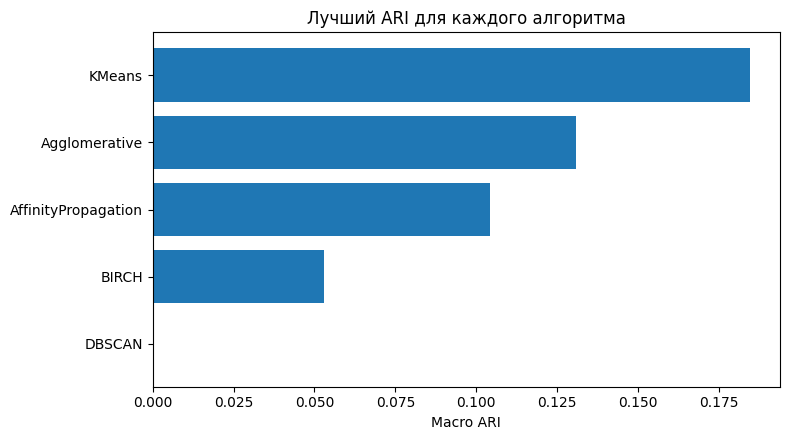

In [13]:
# График: качество лучших конфигураций.
plot_df = best_by_algo.sort_values('macro_ARI', ascending=True)
plt.figure(figsize=(8, 4.5))
plt.barh(plot_df['algorithm'], plot_df['macro_ARI'])
plt.xlabel('Macro ARI')
plt.title('Лучший ARI для каждого алгоритма')
plt.tight_layout()
plt.show()


In [14]:
# Отдельно оцениваем скорость и интуитивность параметров.
# Интуитивность — качественная оценка, она не вычисляется из данных автоматически.
intuition = {
    'KMeans': 'Высокая: главный параметр n_clusters понятен, остальные в основном влияют на устойчивость/сходимость.',
    'Agglomerative': 'Высокая: n_clusters и linkage имеют прозрачный смысл; легко объяснить правило объединения кластеров.',
    'DBSCAN': 'Средняя: eps и min_samples понятны геометрически, но подходящий eps чувствителен к масштабу признаков.',
    'AffinityPropagation': 'Ниже средней: damping понятен как стабилизация, но preference трудно выбирать без анализа шкалы similarities.',
    'BIRCH': 'Средняя/высокая: threshold контролирует компактность подкластеров, branching_factor в основном про структуру CF-дерева.',
}

comparison = best_by_algo[['algorithm', 'macro_ARI', 'time_sec', 'params']].copy()
comparison['parameter_intuitiveness'] = comparison['algorithm'].map(intuition)
comparison = comparison.sort_values('macro_ARI', ascending=False)

display(comparison.style.format({'macro_ARI': '{:.4f}', 'time_sec': '{:.4f}'}))

best_row = comparison.iloc[0]
fastest_row = comparison.sort_values('time_sec').iloc[0]

print('\nИтог задания 2')
print('--------------')
print(f"Лучшее качество в проведённой сетке: {best_row['algorithm']} (macro ARI={best_row['macro_ARI']:.4f}).")
print(f"Самый быстрый из лучших запусков каждого метода: {fastest_row['algorithm']} ({fastest_row['time_sec']:.4f} сек.).")
print(
    'KMeans и агломеративная кластеризация проще всего настраиваются, когда есть разумное ожидание по числу значений. '
    'DBSCAN и AffinityPropagation не требуют заранее фиксировать число кластеров, но их параметры заметно чувствительнее к геометрии embedding-пространства. '
    'BIRCH удобен как дополнительный масштабируемый метод: сначала он сжимает данные в CF-подкластеры, а уже затем выполняет итоговое объединение.'
)


,algorithm,macro_ARI,time_sec,params,parameter_intuitiveness
4,KMeans,0.1846,0.0573,"{""init"": ""random"", ""max_iter"": 300, ""n_clusters"": 2, ""n_init"": 10}","Высокая: главный параметр n_clusters понятен, остальные в основном влияют на устойчивость/сходимость."
1,Agglomerative,0.1310,0.0898,"{""linkage"": ""ward"", ""metric"": ""euclidean"", ""n_clusters"": 2}",Высокая: n_clusters и linkage имеют прозрачный смысл; легко объяснить правило объединения кластеров.
0,AffinityPropagation,0.1043,0.0677,"{""damping"": 0.75, ""max_iter"": 500, ""preference"": -0.5}","Ниже средней: damping понятен как стабилизация, но preference трудно выбирать без анализа шкалы similarities."
2,BIRCH,0.0528,0.0640,"{""branching_factor"": 25, ""n_clusters"": 2, ""threshold"": 0.2}","Средняя/высокая: threshold контролирует компактность подкластеров, branching_factor в основном про структуру CF-дерева."
3,DBSCAN,0.0000,0.0270,"{""eps"": 0.25, ""metric"": ""cosine"", ""min_samples"": 3}","Средняя: eps и min_samples понятны геометрически, но подходящий eps чувствителен к масштабу признаков."



Итог задания 2
--------------
Лучшее качество в проведённой сетке: KMeans (macro ARI=0.1846).
Самый быстрый из лучших запусков каждого метода: DBSCAN (0.0270 сек.).
KMeans и агломеративная кластеризация проще всего настраиваются, когда есть разумное ожидание по числу значений. DBSCAN и AffinityPropagation не требуют заранее фиксировать число кластеров, но их параметры заметно чувствительнее к геометрии embedding-пространства. BIRCH удобен как дополнительный масштабируемый метод: сначала он сжимает данные в CF-подкластеры, а уже затем выполняет итоговое объединение.
